In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from PIL import Image

In [2]:
# Check TensorFlow version
print("TensorFlow version:", tf.version.VERSION)

# Check if TensorFlow can access the GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # If a GPU is available, TensorFlow will automatically use it whenever possible
        print("GPU devices available:", gpus)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU devices available.")

TensorFlow version: 2.10.0
GPU devices available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# df_presto_pass = pd.read_csv('sn_pass_918X_240531.csv').sort_values(by='enddt',ascending=False)[:2500]
df_presto_pass = pd.read_csv('sn_pass_918X_240531.csv')[:2500]
df_presto_fail = pd.read_csv('sn_fail_918X_240531.csv').sort_values(by='enddt',ascending=False)[:7000]
df_sn = pd.concat([df_presto_fail,df_presto_pass])
df_sn = df_sn.drop_duplicates()
df_sn = df_sn.sort_values(by='enddt',ascending=False)
df_sn['adj_pfcode'] = df_sn['pfcode'].apply(lambda x: str(x)[0])
# df_sn = df_sn[df_sn['enddt']< 20240501]
list_sn = tuple(df_sn['hddsn'].unique().tolist())
print('PASS :',len(df_presto_pass),'FAIL :',len(df_presto_fail))
print(df_sn.columns)
df_sn

PASS : 2500 FAIL : 6901
Index(['hddsn', 'procid', 'enddt', 'product', 'pfcode', 'DATA_SEQ',
       'adj_pfcode'],
      dtype='object')


,hddsn,procid,enddt,product,pfcode,DATA_SEQ,adj_pfcode
3561,VY1MJZXM,9187,20240529,vl8,9904,1,9
2842,VY1H849S,9188,20240528,vl8,9904,1,9
2504,VY1R36AM,9188,20240528,vl8,7001,1,7
2100,VY1RU0LS,9188,20240528,vl8,0,1,0
2843,VY1H849S,9188,20240528,vl8,6810,1,6
...,...,...,...,...,...,...,...
3597,VAH4LJ8L,9188,20181118,vl8,6810,1,6
391,VAH3KDUL,9188,20181116,vl8,0,1,0
5694,VAH3A25L,9188,20181115,vl8,6810,1,6
458,VAH3HUYL,9188,20181114,vl8,0,1,0


In [4]:
df_type = pd.read_csv('defect_type.csv')
df_type

,pfcode,count,Error Description,BK,target
0,0,6000,PASS,PASS,PASS
1,9998,1062,Tester error,TESTER_ERROR,TESTER_ERROR
2,9904,768,MPI SCSI Protocal Error,TESTER_ERROR,TESTER_ERROR
3,6813,592,Command Complete Timeout,FAIL,FAIL
4,6804,529,Hard Error,FAIL,FAIL
5,6800,430,Other Error,FAIL,TESTER_ERROR
6,99ZH,413,Power cut,TESTER_ERROR,TESTER_ERROR
7,99XM,282,// G:MPC Reboot,TESTER_ERROR,TESTER_ERROR
8,9920,252,Communication error,TESTER_ERROR,TESTER_ERROR
9,7002,241,TIMEOUT,FAIL,FAIL


In [5]:
df_sn_new = pd.merge(df_sn,df_type,on='pfcode')

In [6]:
df_sn_new

,hddsn,procid,enddt,product,pfcode,DATA_SEQ,adj_pfcode,count,Error Description,BK,target
0,VY1MJZXM,9187,20240529,vl8,9904,1,9,768,MPI SCSI Protocal Error,TESTER_ERROR,TESTER_ERROR
1,VY1H849S,9188,20240528,vl8,9904,1,9,768,MPI SCSI Protocal Error,TESTER_ERROR,TESTER_ERROR
2,VY1R36AM,9188,20240528,vl8,7001,1,7,104,Hard Error,FAIL,FAIL
3,VY1H849S,9188,20240528,vl8,6810,1,6,98,CRC Error,FAIL,FAIL
4,VY1RG2PM,9188,20240527,vl8,7001,1,7,104,Hard Error,FAIL,FAIL
...,...,...,...,...,...,...,...,...,...,...,...
6895,VAH5Y8SL,9188,20181130,vl8,6816,1,6,127,Initial Reassign Check Fail (RDM Entry (>0)),FAIL,TESTER_ERROR
6896,VAH4LB4L,9188,20181118,vl8,6804,1,6,529,Hard Error,FAIL,FAIL
6897,VAH4LJ8L,9188,20181118,vl8,6810,1,6,98,CRC Error,FAIL,FAIL
6898,VAH3A25L,9188,20181115,vl8,6810,1,6,98,CRC Error,FAIL,FAIL


In [7]:
df_sn['enddt'].max()

20240529

In [8]:
df_sn_new['target'].value_counts()

target
TESTER_ERROR    4485
FAIL            2415
Name: count, dtype: int64

In [9]:
df_presto_fail[df_presto_fail['pfcode']!='99ZH'].shape

(6488, 6)

In [10]:
list_fail_real = df_presto_fail['hddsn']

In [11]:
def replace_target(df) :
    if df in list_fail_real.to_list() :
        return 'fail'
    else :
        return 'pass'

In [12]:
list_sn[:3]

('VY1MJZXM', 'VY1H849S', 'VY1R36AM')

In [13]:
df_all_6400 = pd.read_csv('df_all_6400.csv')
df_all_6600 = pd.read_csv('df_all_6600.csv')
df_all_6800 = pd.read_csv('df_all_6800.csv')
df_all_9000 = pd.read_csv('df_all_9000.csv')

In [14]:
print(df_all_6400.shape)
print(df_all_6600.shape)
print(df_all_6800.shape)
print(df_all_9000.shape)

(118170, 855)
(118170, 861)
(118180, 449)
(118110, 5)


In [15]:
df_all_6400[df_all_6400['drive_sn']== 'VDJ57L5F']

,drive_sn,target,physical_head_number,u_last_muec,u_last_uec,u_failed_cmd_name_hi,u_failed_cmd_name_lo,u10n_r_mr,u10n_tfcrramp,u10n_slope1,...,u33n_millipeakgain3,u33n_millipeakfreq1,u33n_millipeakfreq2,u33n_millipeakfreq3,u33n_vcm_bf_gain,u33n_vcm_bf_freq,u10n_uec_1419_count,u10n_uec_143d_count,u10n_uec_143b_count,u10n_uec_1367_count
0,VDJ57L5F,fail,0,-520090104.0,63013.0,1.296332e+09,1.946157e+09,536.0,105.0,-6553500.0,...,-12956.0,56324.0,56324.0,56324.0,-10471.0,4867.0,0.0,0.0,0.0,0.0
1,VDJ57L5F,fail,1,0.0,0.0,0.000000e+00,0.000000e+00,498.0,109.0,-6553500.0,...,-12077.0,56324.0,56324.0,56160.0,-10427.0,4867.0,0.0,0.0,0.0,0.0
106,VDJ57L5F,fail,2,0.0,0.0,0.000000e+00,0.000000e+00,556.0,105.0,-6553500.0,...,-12146.0,56160.0,56489.0,56324.0,-10399.0,4867.0,0.0,0.0,0.0,0.0
107,VDJ57L5F,fail,3,0.0,0.0,0.000000e+00,0.000000e+00,465.0,108.0,-6553500.0,...,-11618.0,55995.0,55995.0,56324.0,-10406.0,4867.0,0.0,0.0,0.0,0.0
108,VDJ57L5F,fail,4,-520090104.0,63013.0,1.296332e+09,1.946157e+09,507.0,110.0,-6553500.0,...,-13337.0,56324.0,56324.0,56324.0,-10375.0,4867.0,0.0,0.0,0.0,0.0
109,VDJ57L5F,fail,5,-520090104.0,63013.0,1.296332e+09,1.946157e+09,398.0,109.0,-6553500.0,...,-11775.0,56324.0,56160.0,56324.0,-10393.0,4867.0,0.0,0.0,0.0,0.0
120,VDJ57L5F,fail,6,0.0,0.0,0.000000e+00,0.000000e+00,654.0,105.0,-6553500.0,...,-13193.0,56324.0,56160.0,56160.0,-10326.0,4867.0,0.0,0.0,0.0,0.0
121,VDJ57L5F,fail,7,0.0,0.0,0.000000e+00,0.000000e+00,603.0,108.0,-6553500.0,...,-11854.0,56160.0,56160.0,56324.0,-10352.0,4867.0,0.0,0.0,0.0,0.0
124,VDJ57L5F,fail,8,-520090104.0,63013.0,1.296332e+09,1.946157e+09,560.0,107.0,-6553500.0,...,-12596.0,56324.0,56324.0,56324.0,-10321.0,4867.0,0.0,0.0,0.0,0.0
125,VDJ57L5F,fail,9,0.0,0.0,0.000000e+00,0.000000e+00,506.0,107.0,-6553500.0,...,-13333.0,56324.0,56324.0,56324.0,-10344.0,4867.0,0.0,0.0,0.0,0.0


In [16]:
import pandas as pd

# Define the aggregation functions for the columns
print('Define the aggregation functions for the columns')
agg_funcs_6400 = {column: ['min', 'mean', 'max', 'std'] for column in df_all_6400.columns[2:]}
agg_funcs_6600 = {column: ['min', 'mean', 'max', 'std'] for column in df_all_6600.columns[2:]}
agg_funcs_6800 = {column: ['min', 'mean', 'max', 'std'] for column in df_all_6800.columns[2:]}
agg_funcs_9000 = {column: ['min', 'mean', 'max', 'std'] for column in df_all_9000.columns[2:]}

print('Perform groupby and aggregate the basic statistics')
# Perform groupby and aggregate the basic statistics
df_grouped_6400 = df_all_6400.groupby(['drive_sn', 'target']).agg(agg_funcs_6400)
df_grouped_6600 = df_all_6600.groupby(['drive_sn', 'target']).agg(agg_funcs_6600)
df_grouped_6800 = df_all_6800.groupby(['drive_sn', 'target']).agg(agg_funcs_6800)
df_grouped_9000 = df_all_9000.groupby(['drive_sn', 'target']).agg(agg_funcs_9000)

print('Flatten the multi-level columns created by aggregation')
# Flatten the multi-level columns created by aggregation
df_grouped_6400.columns = ['{}_{}'.format(col[0], col[1]) for col in df_grouped_6400.columns]
df_grouped_6600.columns = ['{}_{}'.format(col[0], col[1]) for col in df_grouped_6600.columns]
df_grouped_6800.columns = ['{}_{}'.format(col[0], col[1]) for col in df_grouped_6800.columns]
df_grouped_9000.columns = ['{}_{}'.format(col[0], col[1]) for col in df_grouped_9000.columns]

# Now calculate quantiles separately
def add_quantiles(df, groupby_cols, quantiles=[0.25, 0.5, 0.75]):
    quantile_df = df.groupby(groupby_cols).quantile(quantiles)
    quantile_df = quantile_df.unstack(level=-1)
    quantile_df.columns = [f'{col[0]}_quantile_{int(col[1]*100)}' for col in quantile_df.columns]
    return quantile_df

print('Now calculate quantiles separately')
quantile_6400 = add_quantiles(df_all_6400, ['drive_sn', 'target'])
quantile_6600 = add_quantiles(df_all_6600, ['drive_sn', 'target'])
quantile_6800 = add_quantiles(df_all_6800, ['drive_sn', 'target'])
quantile_9000 = add_quantiles(df_all_9000, ['drive_sn', 'target'])

print('Combine the original statistics with the quantiles')
# Combine the original statistics with the quantiles
df_statistics_6400 = pd.concat([df_grouped_6400, quantile_6400], axis=1)
df_statistics_6600 = pd.concat([df_grouped_6600, quantile_6600], axis=1)
df_statistics_6800 = pd.concat([df_grouped_6800, quantile_6800], axis=1)
df_statistics_9000 = pd.concat([df_grouped_9000, quantile_9000], axis=1)


print('Combine the original statistics with the quantiles')
# Combine the original statistics with the quantiles
df_statistics_6400 = pd.concat([df_grouped_6400, quantile_6400], axis=1)
df_statistics_6600 = pd.concat([df_grouped_6600, quantile_6600], axis=1)
df_statistics_6800 = pd.concat([df_grouped_6800, quantile_6800], axis=1)
df_statistics_9000 = pd.concat([df_grouped_9000, quantile_9000], axis=1)


Define the aggregation functions for the columns
Perform groupby and aggregate the basic statistics
Flatten the multi-level columns created by aggregation
Now calculate quantiles separately
Combine the original statistics with the quantiles
Combine the original statistics with the quantiles


In [17]:
df_merged_statistics = df_statistics_6400.merge(
    df_statistics_6600, on=['drive_sn'], how='inner', suffixes=('_6400', '_6600')
)
df_merged_statistics = df_merged_statistics.merge(
    df_statistics_6800, on=['drive_sn'], how='inner', suffixes=('', '_6800')
)
df_merged_statistics = df_merged_statistics.merge(
    df_statistics_9000, on=['drive_sn'], how='inner', suffixes=('_final', '_9000')
)
df_merged_statistics = df_merged_statistics.reset_index()

In [18]:
df_merged_statistics

,drive_sn,physical_head_number_min_6400,physical_head_number_mean_6400,physical_head_number_max_6400,physical_head_number_std_6400,u_last_muec_min,u_last_muec_mean,u_last_muec_max,u_last_muec_std,u_last_uec_min,...,e_error_cnt_ovd_std,physical_head_number_quantile_25_9000,physical_head_number_quantile_50_9000,physical_head_number_quantile_75_9000,e_head_vga_ratio_ovd_quantile_25,e_head_vga_ratio_ovd_quantile_50,e_head_vga_ratio_ovd_quantile_75,e_error_cnt_ovd_quantile_25,e_error_cnt_ovd_quantile_50,e_error_cnt_ovd_quantile_75
0,VAGGMG5L,0,4.5,9,3.02765,-520090104.0,-260045052.0,0.0,2.741116e+08,0.0,...,0.0,2.25,4.5,6.75,99.25,100.0,100.00,0.0,0.0,0.0
1,VAGK18ZL,0,4.5,9,3.02765,-520090104.0,-468081093.6,0.0,1.644669e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,100.0,100.00,0.0,0.0,0.0
2,VAGKEJHL,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,100.0,100.00,0.0,0.0,0.0
3,VAGLM64L,0,4.5,9,3.02765,-520090104.0,-104018020.8,0.0,2.192892e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,101.0,101.00,0.0,0.0,0.0
4,VAGN0DNL,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,100.0,100.75,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11804,VYKKT8LM,0,4.5,9,3.02765,-520090104.0,-364063072.8,0.0,2.512274e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,100.0,100.00,0.0,0.0,0.0
11805,VYKKTV9M,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,98.25,99.0,99.00,0.0,0.0,0.0
11806,VYKKTXSM,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,96.25,99.0,100.00,0.0,0.0,0.0
11807,VYKKU01M,0,4.5,9,3.02765,-520090104.0,-156027031.2,0.0,2.512274e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,99.5,100.00,0.0,0.0,0.0


In [19]:
df_merged_statistics_bk = df_merged_statistics.copy()

In [37]:
df_merged_statistics_bk

,drive_sn,physical_head_number_min_6400,physical_head_number_mean_6400,physical_head_number_max_6400,physical_head_number_std_6400,u_last_muec_min,u_last_muec_mean,u_last_muec_max,u_last_muec_std,u_last_uec_min,...,e_error_cnt_ovd_std,physical_head_number_quantile_25_9000,physical_head_number_quantile_50_9000,physical_head_number_quantile_75_9000,e_head_vga_ratio_ovd_quantile_25,e_head_vga_ratio_ovd_quantile_50,e_head_vga_ratio_ovd_quantile_75,e_error_cnt_ovd_quantile_25,e_error_cnt_ovd_quantile_50,e_error_cnt_ovd_quantile_75
0,VAGGMG5L,0,4.5,9,3.02765,-520090104.0,-260045052.0,0.0,2.741116e+08,0.0,...,0.0,2.25,4.5,6.75,99.25,100.0,100.00,0.0,0.0,0.0
1,VAGK18ZL,0,4.5,9,3.02765,-520090104.0,-468081093.6,0.0,1.644669e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,100.0,100.00,0.0,0.0,0.0
2,VAGKEJHL,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,100.0,100.00,0.0,0.0,0.0
3,VAGLM64L,0,4.5,9,3.02765,-520090104.0,-104018020.8,0.0,2.192892e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,101.0,101.00,0.0,0.0,0.0
4,VAGN0DNL,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,100.0,100.75,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11804,VYKKT8LM,0,4.5,9,3.02765,-520090104.0,-364063072.8,0.0,2.512274e+08,0.0,...,0.0,2.25,4.5,6.75,100.00,100.0,100.00,0.0,0.0,0.0
11805,VYKKTV9M,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,98.25,99.0,99.00,0.0,0.0,0.0
11806,VYKKTXSM,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,0.0,2.25,4.5,6.75,96.25,99.0,100.00,0.0,0.0,0.0
11807,VYKKU01M,0,4.5,9,3.02765,-520090104.0,-156027031.2,0.0,2.512274e+08,0.0,...,0.0,2.25,4.5,6.75,99.00,99.5,100.00,0.0,0.0,0.0


In [20]:
df_sn_new[df_sn_new['target']=='FAIL']

,hddsn,procid,enddt,product,pfcode,DATA_SEQ,adj_pfcode,count,Error Description,BK,target
2,VY1R36AM,9188,20240528,vl8,7001,1,7,104,Hard Error,FAIL,FAIL
3,VY1H849S,9188,20240528,vl8,6810,1,6,98,CRC Error,FAIL,FAIL
4,VY1RG2PM,9188,20240527,vl8,7001,1,7,104,Hard Error,FAIL,FAIL
5,VY10LUAM,9188,20240525,vl8,6804,1,6,529,Hard Error,FAIL,FAIL
7,VY1HX0YM,9188,20240520,vl8,7000,1,7,121,Other,FAIL,FAIL
...,...,...,...,...,...,...,...,...,...,...,...
6893,VAH4JAEL,9188,20181205,vl8,7000,1,7,121,Other,FAIL,FAIL
6894,VAGS5UTL,9188,20181203,vl8,7002,1,7,241,TIMEOUT,FAIL,FAIL
6896,VAH4LB4L,9188,20181118,vl8,6804,1,6,529,Hard Error,FAIL,FAIL
6897,VAH4LJ8L,9188,20181118,vl8,6810,1,6,98,CRC Error,FAIL,FAIL


In [21]:
df_merged_statistics = df_merged_statistics.merge(
    df_sn_new[df_sn_new['target']=='FAIL'][['hddsn', 'target']], 
    right_on=['hddsn'], 
    left_on=['drive_sn'], 
    how='left'
)

df_merged_statistics.drop(columns=['hddsn'], inplace=True)
df_merged_statistics['target'].fillna("PASS", inplace=True)

C:\Users\1000305259\AppData\Local\Temp\ipykernel_96160\2769410823.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_merged_statistics['target'].fillna("PASS", inplace=True)


In [22]:
df_merged_statistics['target'].value_counts()

target
PASS    9761
FAIL    2065
Name: count, dtype: int64

In [23]:
result = df_merged_statistics

In [24]:
result['target'].value_counts()

target
PASS    9761
FAIL    2065
Name: count, dtype: int64

In [40]:
import pandas as pd

# Assuming your DataFrame is named `df` and has a column named 'target'
# Separate the classes
pass_data = result[result['target'] == 'PASS']
fail_data = result[result['target'] == 'FAIL']

# Undersample the PASS class to match the size of the FAIL class
pass_data_balanced = pass_data.sample(n=2048, random_state=42)

# Combine the undersampled PASS data with the FAIL data
balanced_df = pd.concat([pass_data_balanced, fail_data])

# Shuffle the dataset to mix the classes
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the new class distribution
print(balanced_df['target'].value_counts())


target
PASS    2048
FAIL    2048
Name: count, dtype: int64


In [41]:
balanced_df

,drive_sn,physical_head_number_min_6400,physical_head_number_mean_6400,physical_head_number_max_6400,physical_head_number_std_6400,u_last_muec_min,u_last_muec_mean,u_last_muec_max,u_last_muec_std,u_last_uec_min,...,physical_head_number_quantile_25_9000,physical_head_number_quantile_50_9000,physical_head_number_quantile_75_9000,e_head_vga_ratio_ovd_quantile_25,e_head_vga_ratio_ovd_quantile_50,e_head_vga_ratio_ovd_quantile_75,e_error_cnt_ovd_quantile_25,e_error_cnt_ovd_quantile_50,e_error_cnt_ovd_quantile_75,target
0,VR1018KK,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,99.0,99.5,100.00,0.0,0.0,0.0,PASS
1,VY1MKNMM,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,99.0,100.0,100.00,0.0,0.0,0.0,PASS
2,VYGHZZGM,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,100.0,101.0,101.00,0.0,0.0,0.0,FAIL
3,VAHM7K6L,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,99.0,99.5,100.00,0.0,0.0,0.0,FAIL
4,VGKRAL1G,0,4.5,9,3.02765,-520090104.0,-364063072.8,0.0,2.512274e+08,0.0,...,2.25,4.5,6.75,100.0,101.0,101.00,0.0,0.0,0.0,PASS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,VG0464WG,0,4.5,9,3.02765,-520090104.0,-208036041.6,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.75,0.0,0.0,0.0,PASS
4092,VRGJVU8K,0,4.5,9,3.02765,-520090104.0,-208036041.6,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,99.0,99.0,99.00,0.0,0.0,0.0,PASS
4093,VGJWX13G,0,4.5,9,3.02765,-520090104.0,-156027031.2,0.0,2.512274e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.00,0.0,0.0,0.0,PASS
4094,VRJ9L0DK,0,4.5,9,3.02765,-520090104.0,-260045052.0,0.0,2.741116e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.00,0.0,0.0,0.0,FAIL


In [42]:
# def tar_num(df) :
#     if df == 'pass' : return 0
#     if df == 'fail' : return 1

# result['target_num'] = result['target'].apply(tar_num)

In [43]:
balanced_df.head(5).to_csv('example.csv',index=False)

In [45]:
# result.to_csv('df_merged_statistics.csv',index=False)
balanced_df

,drive_sn,physical_head_number_min_6400,physical_head_number_mean_6400,physical_head_number_max_6400,physical_head_number_std_6400,u_last_muec_min,u_last_muec_mean,u_last_muec_max,u_last_muec_std,u_last_uec_min,...,physical_head_number_quantile_25_9000,physical_head_number_quantile_50_9000,physical_head_number_quantile_75_9000,e_head_vga_ratio_ovd_quantile_25,e_head_vga_ratio_ovd_quantile_50,e_head_vga_ratio_ovd_quantile_75,e_error_cnt_ovd_quantile_25,e_error_cnt_ovd_quantile_50,e_error_cnt_ovd_quantile_75,target
0,VR1018KK,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,99.0,99.5,100.00,0.0,0.0,0.0,PASS
1,VY1MKNMM,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,99.0,100.0,100.00,0.0,0.0,0.0,PASS
2,VYGHZZGM,0,4.5,9,3.02765,-520090104.0,-416072083.2,0.0,2.192892e+08,0.0,...,2.25,4.5,6.75,100.0,101.0,101.00,0.0,0.0,0.0,FAIL
3,VAHM7K6L,0,4.5,9,3.02765,-520090104.0,-312054062.4,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,99.0,99.5,100.00,0.0,0.0,0.0,FAIL
4,VGKRAL1G,0,4.5,9,3.02765,-520090104.0,-364063072.8,0.0,2.512274e+08,0.0,...,2.25,4.5,6.75,100.0,101.0,101.00,0.0,0.0,0.0,PASS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,VG0464WG,0,4.5,9,3.02765,-520090104.0,-208036041.6,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.75,0.0,0.0,0.0,PASS
4092,VRGJVU8K,0,4.5,9,3.02765,-520090104.0,-208036041.6,0.0,2.685734e+08,0.0,...,2.25,4.5,6.75,99.0,99.0,99.00,0.0,0.0,0.0,PASS
4093,VGJWX13G,0,4.5,9,3.02765,-520090104.0,-156027031.2,0.0,2.512274e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.00,0.0,0.0,0.0,PASS
4094,VRJ9L0DK,0,4.5,9,3.02765,-520090104.0,-260045052.0,0.0,2.741116e+08,0.0,...,2.25,4.5,6.75,100.0,100.0,100.00,0.0,0.0,0.0,FAIL


In [46]:
balanced_df.drop_duplicates(subset=['drive_sn'], inplace=True)
balanced_df.shape

(4096, 15136)

In [47]:
x = balanced_df.drop(['drive_sn','target'],axis=1)
y = balanced_df['target']

In [48]:
scaler = StandardScaler()
scaler_minmax = MinMaxScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = scaler_minmax.fit_transform(X_scaled)

In [49]:
number_add_data = 10

In [50]:
X_scaled.shape

(4096, 15134)

In [51]:
X_scaled.max()

1.0000000000000002

In [52]:
current_shape = X_scaled.shape

zeros_to_add = np.zeros((current_shape[0], 418))

X_scaled_with_zeros_column = np.concatenate((X_scaled, zeros_to_add), axis=1)

print(X_scaled_with_zeros_column.shape)


(4096, 15552)


In [53]:
pd.DataFrame(X_scaled_with_zeros_column)

,0,1,2,3,4,5,6,7,8,9,...,15542,15543,15544,15545,15546,15547,15548,15549,15550,15551
0,0.0,0.0,0.0,0.0,0.0,0.2,0.645832,0.693299,0.0,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.2,0.645832,0.693299,0.0,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.2,0.645832,0.693299,0.0,0.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.4,0.645832,0.849115,0.0,0.6,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.3,0.645832,0.794274,0.0,0.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.0,0.0,0.0,0.0,0.0,0.6,0.645832,0.849115,0.0,0.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4092,0.0,0.0,0.0,0.0,0.0,0.6,0.645832,0.849115,0.0,0.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4093,0.0,0.0,0.0,0.0,0.0,0.7,0.645832,0.794274,0.0,0.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4094,0.0,0.0,0.0,0.0,0.0,0.5,0.645832,0.866624,0.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [65]:
# Assuming X_scaled_with_zeros_column is a DataFrame or a 2D NumPy array with shape (11809, 15552)
# Initialize a new reshaped array with 3 layers for each row
reshaped_data = np.zeros((X_scaled_with_zeros_column.shape[0], 3, 5184))  # 15552 / 3 = 5184 columns per layer

# Iterate over each row to split it into 3 layers
for row in range(X_scaled_with_zeros_column.shape[0]):
    for i in range(X_scaled_with_zeros_column.shape[1]):
        layer = i % 3  # Alternate between layers 0, 1, and 2
        col = i // 3   # Every third value is assigned to the same column across layers
        reshaped_data[row, layer, col] = X_scaled_with_zeros_column[row, i]

In [66]:
reshaped_data.shape

(4096, 3, 5184)

In [67]:
reshaped_data.shape[1:3]

(3, 5184)

In [68]:
reshaped_data.max()

1.0000000000000002

(4096, 3, 5184)
(4096, 72, 72, 3)
1.0


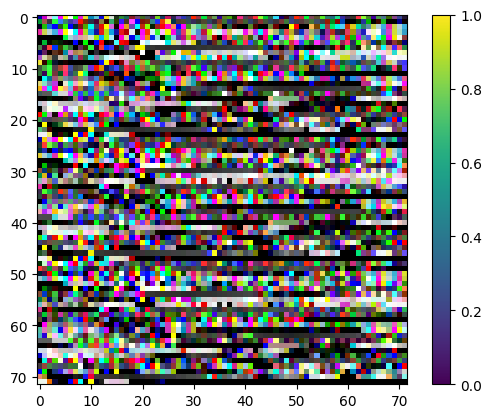

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming reshaped_data is of shape (11809, 3, 5184)
data = reshaped_data

# Reshape the data for visualization purposes
# Reshape to (11809, 72, 72, 3) if you have images of size 72x72
print(reshaped_data.shape)
data = data.reshape((X_scaled_with_zerosQ_column.shape[0], 72, 72, 3))
print(data.shape)
QQQ
# Ensure values are in the range [0, 1]
data = np.clip(data, 0, 1)  # Ensures no values exceed 1

# # Create a mask where all three channels are >= 0.9
# mask = (data[:, :, :, 0] >= 0.9) & (data[:, :, :, 1] >= 0.9) & (data[:, :, :, 2] >= 0.9)
# # Create a mask where all three channels are 0
# mask2 = (data[:, :, :, 0] == 0) & (data[:, :, :, 1] == 0) & (data[:, :, :, 2] == 0)

# Apply the mask to set those values to 0.5
# data[mask] = 0.5
# data[mask2] = 0.0

# Verify changes (optional)
print(data.max())

# Display the first image as an example
plt.imshow(data[0])  # Display the data as an image, assuming RGB format
plt.colorbar()  # Optional: Adds a colorbar to interpret the values
plt.show()  # Display the image


In [70]:
data.shape

(4096, 72, 72, 3)

In [71]:
import tensorflow as tf

def resize_images(X):
    resized = np.array([tf.image.resize(img, (224, 224)).numpy() for img in X])
    del X  # Free the original data
    tf.keras.backend.clear_session()  # Clear TensorFlow session to release memory
    return resized

# data_resized = resize_images(data)

In [72]:
data.shape

(4096, 72, 72, 3)

In [73]:
# data_resized.shape

In [74]:
y.shape

(4096,)

In [75]:
X_train, X_temp, y_train, y_temp = train_test_split(data, y, test_size=0.25, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [76]:
# Assuming your NumPy array is named `array` and your y dataset is named `y`
array = X_train
y = y_train

# Define the base directory
base_dir = 'img_241215/train'

# Get unique labels from y and create a folder for each
unique_labels = y.unique()
for label in unique_labels:
    os.makedirs(os.path.join(base_dir, f'{label}'), exist_ok=True)

# Save each image to the folder corresponding to its label
for i in range(array.shape[0]):
    img = Image.fromarray((array[i] * 255).astype(np.uint8))  # Normalize the array values to [0, 255]
    label = y.iloc[i]
    img.save(os.path.join(base_dir, f'{label}', f'image_{i}.png'))

# Assuming your NumPy array is named `array` and your y dataset is named `y`
array = X_test
y = y_test

# Define the base directory
base_dir = 'img_241215/test'

# Get unique labels from y and create a folder for each
unique_labels = y.unique()
for label in unique_labels:
    os.makedirs(os.path.join(base_dir, f'{label}'), exist_ok=True)

# Save each image to the folder corresponding to its label
for i in range(array.shape[0]):
    img = Image.fromarray((array[i] * 255).astype(np.uint8))  # Normalize the array values to [0, 255]
    label = y.iloc[i]
    img.save(os.path.join(base_dir, f'{label}', f'image_{i}.png'))


# Assuming your NumPy array is named `array` and your y dataset is named `y`
array = X_val
y = y_val

# Define the base directory
base_dir = 'img_241215/validate'

# Get unique labels from y and create a folder for each
unique_labels = y.unique()
for label in unique_labels:
    os.makedirs(os.path.join(base_dir, f'{label}'), exist_ok=True)

# Save each image to the folder corresponding to its label
for i in range(array.shape[0]):
    img = Image.fromarray((array[i] * 255).astype(np.uint8))  # Normalize the array values to [0, 255]
    label = y.iloc[i]
    img.save(os.path.join(base_dir, f'{label}', f'image_{i}.png'))